In [ ]:
!pip install imbalanced-learn

# Install the `imbalanced-learn` library (imported in code as `imblearn`),
# a scikit-learn-compatible package specifically built for handling
# CLASS IMBALANCE — situations where one class in a classification
# problem has far more samples than another (e.g. fraud detection,
# where "fraud" cases might be <1% of the data, or medical diagnosis,
# where the positive/rare condition is a small minority).
#
# The leading `!` runs this as a shell command directly from the
# notebook cell (rather than as Python code) — the standard way to
# install packages inside Jupyter/Colab notebooks.
#
# `imbalanced-learn` provides tools that plug directly into scikit-learn
# pipelines to address imbalance, broadly falling into three families:
#   - Over-sampling: create more samples of the minority class
#     (e.g. SMOTE — Synthetic Minority Oversampling Technique, which
#     generates new synthetic minority points by interpolating between
#     existing ones, rather than just duplicating them).
#   - Under-sampling: remove some samples from the majority class,
#     to bring the class sizes closer together.
#   - Combined methods: mix over- and under-sampling.

We are importing the necessary libraries. `matplotlib` for plotting, `sklearn` for data generation, model training, and evaluation, and `imbalanced-learn` for re-sampling strategies.


In [ ]:
# Importing necessary libraries
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
# A function to GENERATE a synthetic classification dataset with
# controllable properties — including, importantly, controllable class
# imbalance (via a `weights` parameter). This plays the same role
# make_swiss_roll played for the manifold-learning notebooks: a
# purpose-built synthetic example to clearly demonstrate the technique
# (here, class imbalance) without needing a real dataset with the
#"right" characteristics already baked in.

from sklearn.linear_model import LogisticRegression
# A simple, standard classification model , logistic regression is literally a one-layer
# neural network with a sigmoid activation. It's commonly used here
# as a baseline classifier to demonstrate the PRACTICAL EFFECT of
# class imbalance on model performance, since it's fast, simple, and
# its weaknesses on imbalanced data are well understood.

from sklearn.metrics import classification_report
# A utility that prints a summary of classification performance —
# precision, recall, F1-score, and support (sample count) PER CLASS,
# plus overall accuracy. This is the key diagnostic tool for imbalance
# problems specifically, since overall accuracy alone can look
# deceptively high on imbalanced data (a model that always predicts
# the majority class can still get high accuracy) — per-class recall
# is what actually reveals whether the minority class is being
# detected at all.

from sklearn.model_selection import train_test_split
# Splits data into training and test sets — standard practice so the
# model is evaluated on data it didn't see during training, giving an
# honest estimate of real-world performance.

from imblearn.under_sampling import RandomUnderSampler
# From the imbalanced-learn library just installed: a resampling tool
# that BALANCES classes by randomly removing samples from the
# majority class, until the class sizes are more equal (or reach a
# specified ratio).

from imblearn.over_sampling import RandomOverSampler
# The counterpart: balances classes by randomly DUPLICATING samples
# from the minority class instead, growing it to better match the
# majority class size — the opposite strategy, addressed by removing
# fewer real data points, but at the cost of introducing exact
# duplicate rows rather than new information.

import numpy as np

Here, we generate a synthetic imbalanced dataset using the `make_classification` function from scikit-learn, and then split it into training and testing sets using the `train_test_split` function.

## Hold-out (set)

A **hold-out set** is a portion of a dataset that is deliberately set aside and *not* used during model training, so it can later be used to evaluate how well the trained model performs on data it has never seen before.

**Why it matters:** a model's performance measured on the *same* data it was trained on is a poor estimate of real-world performance — the model can simply memorize patterns specific to that data (overfitting) and appear to perform far better than it actually would on new, unseen inputs. Holding out a separate portion of data and only evaluating on it *after* training gives an honest, unbiased estimate of generalization performance.

**In this notebook:** `train_test_split(X, y, test_size=0.2, random_state=42)` is exactly this — it creates a hold-out set by setting aside 20% of the data (`X_test`, `y_test`, 400 samples) that the model never sees during `.fit()`. `classification_report(y_test, clf.predict(X_test))` then evaluates the trained classifier only on this hold-out portion, which is why the 0.00 recall for class 1 is a trustworthy signal of a real problem — not an artifact of testing on training data.

**A note on terminology, since it comes up often:** "hold-out set" and "test set" are frequently used interchangeably (as in this notebook). More precisely, some workflows distinguish three splits:

- **Training set** — used to fit the model.
- **Validation set** — a hold-out portion used *during* development, e.g. for tuning hyperparameters or deciding when to stop training.
- **Test set** — a *final* hold-out portion touched only once, at the very end, to report final performance.

In simpler setups like this one (a single `train_test_split` into train/test), "hold-out set" and "test set" refer to the same 20% split.

In [ ]:
# Create a synthetic imbalanced dataset
X, y = make_classification(
    n_classes=2, class_sep=0.6,
    weights=[0.90, 0.10],  # 90% of samples belong to class 0
    n_informative=3, n_redundant=0,
    flip_y=0, n_features=10,
    n_clusters_per_class=1, n_samples=2000,
    random_state=42
)
# Generate a synthetic binary classification dataset with deliberate
# class imbalance:
#   - n_classes=2: two target classes (0 and 1) — a standard binary
#     classification setup.
#   - class_sep=0.6: controls how far apart the two classes' clusters
#     are in feature space. Lower values make the classes harder to
#     separate (more overlapping) — 0.6 is a moderate value, making
#     this a realistically non-trivial classification problem, not a
#     trivially easy one.
#   - weights=[0.90, 0.10]: THIS is the imbalance itself — 90% of the
#     2000 samples belong to class 0, only 10% to class 1. Running
#     this confirms exactly that: 1800 samples of class 0, 200 of
#     class 1.
#   - n_informative=3: 3 of the features actually carry real signal
#     useful for predicting the class.
#   - n_redundant=0: none of the features are redundant (linear
#     combinations of the informative ones) — every feature is either
#     informative or pure noise.
#   - flip_y=0: no label noise — 0% of labels are randomly flipped, so
#     the class assignment is "clean" (no artificially mislabeled
#     samples), keeping the imbalance itself as the only challenge
#     being demonstrated, without adding noisy labels as a confound.
#   - n_features=10: 10 total input features (3 informative, 0
#     redundant, so the remaining 7 are pure noise features).
#   - n_clusters_per_class=1: each class forms a single, compact
#     cluster in feature space, rather than being split into multiple
#     sub-clusters — a simpler, easier-to-visualize class structure.
#   - n_samples=2000: 2000 total samples, X shape (2000, 10),
#     y shape (2000,).
#   - random_state=42: fixes the random generation, so the exact same
#     dataset is produced every time this cell runs.

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Split the 2000 samples into a training set (80%) and a held-out test
# set (20%), so the model can later be evaluated on data it never saw
# during training:
#   - X_train, y_train: 1600 samples for training.
#   - X_test, y_test: 400 samples for final evaluation.
#   - random_state=42: fixes which specific samples land in train vs.
#     test, for reproducibility.
#
# Importantly, train_test_split does NOT automatically preserve the
# original 90/10 class ratio in each split unless explicitly told to
# (via a `stratify=y` argument, which is notably absent here). Running
# this confirms the imbalance ratio drifted slightly by chance between
# the two splits:
#   Train: 1442 class-0 / 158 class-1  (≈ 90.1% / 9.9%)
#   Test:    358 class-0 /  42 class-1  (≈ 89.5% / 10.5%)
# Close to the original 90/10 split, but not exact — worth keeping in
# mind, since without stratification, a smaller dataset or a more
# extreme imbalance ratio could produce a test set with a noticeably
# different class balance than the training set purely by random
# chance.

We train a logistic regression classifier on the original (imbalanced) data and evaluate its performance on the testing set using a classification report, which provides precision, recall, and F1-score.

In [ ]:
# Train a logistic regression classifier on the original data
clf = LogisticRegression(random_state=42)
# Create a logistic regression model instance. random_state=42 fixes
# any internal randomness (e.g. in the solver's optimization process),
# for reproducibility.

clf.fit(X_train, y_train)
# Train the model on the 1600-sample training set — logistic
# regression learns weights that minimize classification error
# (technically, log-loss) on this data. No special handling of the
# class imbalance is applied here — the model is trained exactly as
# it would be on a balanced dataset, which is the point of this cell:
# to first show what happens WITHOUT any imbalance correction, as a
# baseline to compare the resampling methods against later.

print("Classification Report on Original Data:")
print(classification_report(y_test, clf.predict(X_test)))
# Generate predictions on the held-out 400-sample test set, then print
# a full per-class breakdown: precision, recall, F1-score, and support
# (sample count) for each class, plus overall accuracy.

Classification Report on Original Data:
              precision    recall  f1-score   support

           0       0.89      0.98      0.93       358
           1       0.00      0.00      0.00        42

    accuracy                           0.88       400
   macro avg       0.45      0.49      0.47       400
weighted avg       0.80      0.88      0.84       400



We apply under-sampling to balance the class distribution in the training data, train a new logistic regression classifier on the under-sampled data, and evaluate its performance on the testing set.

In [ ]:
# Under-sampling
rus = RandomUnderSampler(random_state=42)
# Create a RandomUnderSampler instance — by default, it balances
# classes by randomly discarding majority-class samples until both
# classes have the SAME count as the minority class. random_state=42
# fixes which specific majority samples get dropped, for reproducibility.

X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)
# Apply the resampling to the TRAINING set only (not the test set —
# this is important: the test set must stay untouched and reflect
# real-world class proportions, so evaluation remains honest; only the
# data the model learns FROM gets rebalanced).
# `fit_resample` combines learning the class counts and performing the
# resampling in one call, mirroring the fit_transform pattern seen
# throughout this notebook.
# Since the original X_train had 1442 class-0 and 158 class-1 samples,
# RandomUnderSampler drops class-0 samples down to match class-1's
# count: X_train_rus ends up with (158 + 158) = 316 samples total,
# an exact 50/50 split — confirmed by the actual run: shape (316, 10),
# class counts [158, 158].

# Train a logistic regression classifier on the under-sampled data
clf_rus = LogisticRegression(random_state=42)
clf_rus.fit(X_train_rus, y_train_rus)
# Train a FRESH logistic regression model (a new instance, clf_rus,
# not reusing the earlier clf) on the balanced 316-sample training
# set — same training procedure as before, just on rebalanced data.

print("Classification Report on Under-sampled Data:")
print(classification_report(y_test, clf_rus.predict(X_test)))
# Evaluate on the SAME untouched 400-sample hold-out set used for the
# original model, so the two classification reports are directly
# comparable — isolating the effect of under-sampling as the only
# variable that changed.

Classification Report on Under-sampled Data:
              precision    recall  f1-score   support

           0       1.00      0.76      0.86       358
           1       0.33      1.00      0.49        42

    accuracy                           0.79       400
   macro avg       0.66      0.88      0.68       400
weighted avg       0.93      0.79      0.82       400



### Actual Output
          precision    recall  f1-score   support

       0       1.00      0.76      0.86       358
       1       0.33      1.00      0.49        42

accuracy                           0.79       400

### Comparison with the Original (Imbalanced) Model

| | Original (imbalanced) | Under-sampled |
|---|---|---|
| Class 1 recall | 0.00 | **1.00** |
| Class 1 precision | 0.00 | 0.33 |
| Class 1 F1 | 0.00 | 0.49 |
| Overall accuracy | 0.88 | 0.79 |

This is the trade-off under-sampling makes visible: **recall for class 1 jumped from 0 to a perfect 1.00** — the model now catches *every* minority-class case in the test set, exactly the failure the original model had. But this comes at a cost: **class 1 precision is only 0.33**, meaning the model now also flags plenty of class-0 samples as class-1 by mistake, and **overall accuracy actually dropped** from 0.88 to 0.79.

This drop in accuracy is expected and not a bug — it's the direct consequence of forcing the model to stop defaulting to "always predict the majority class." In a real application (e.g. fraud detection), whether this trade-off is worth it depends entirely on the relative cost of a **false negative** (missing a real fraud case) vs. a **false positive** (flagging a legitimate transaction) — which is exactly the kind of judgment call `classification_report`'s full breakdown, rather than accuracy alone, is meant to inform.

Similarly, we apply over-sampling to balance the class distribution in the training data, train a new logistic regression classifier on the over-sampled data, and evaluate its performance on the testing set.

In [ ]:
## Over-Sampling
ros = RandomOverSampler(random_state=42)
# Create a RandomOverSampler instance — the opposite strategy to
# RandomUnderSampler: instead of removing majority-class samples, it
# balances classes by randomly DUPLICATING minority-class samples
# until both classes have the SAME count as the majority class.
# random_state=42 fixes which specific minority samples get
# duplicated (and how many times), for reproducibility.

X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)
# Apply the resampling to the TRAINING set only — same principle as
# under-sampling: the test set stays untouched so evaluation remains
# honest.
# Since X_train had 1442 class-0 and 158 class-1 samples,
# RandomOverSampler duplicates class-1 samples up to match class-0's
# count: X_train_ros ends up with (1442 + 1442) = 2884 samples total,
# an exact 50/50 split — confirmed by the actual run: shape (2884, 10),
# class counts [1442, 1442]. Note this is nearly 9x more samples than
# under-sampling's 316-row result, since over-sampling grows the
# minority class up to the majority's size rather than shrinking the
# majority down to the minority's.

# Train a logistic regression classifier on the over-sampled data
clf_ros = LogisticRegression(random_state=42)
clf_ros.fit(X_train_ros, y_train_ros)
# Train another fresh logistic regression model (clf_ros) on the
# balanced 2884-sample training set.

print("Classification Report on Over-sampled Data:")
print(classification_report(y_test, clf_ros.predict(X_test)))
# Evaluate on the same untouched 400-sample hold-out set, so all three
# models (original, under-sampled, over-sampled) are directly comparable.


Classification Report on Over-sampled Data:
              precision    recall  f1-score   support

           0       1.00      0.75      0.86       358
           1       0.32      1.00      0.49        42

    accuracy                           0.78       400
   macro avg       0.66      0.88      0.67       400
weighted avg       0.93      0.78      0.82       400



### Actual Output
          precision    recall  f1-score   support

       0       1.00      0.75      0.86       358
       1       0.32      1.00      0.49        42

accuracy                           0.78       400

### Comparison Across All Three Models

| | Original (imbalanced) | Under-sampled | Over-sampled |
|---|---|---|---|
| Training samples used | 1600 | 316 | 2884 |
| Class 1 recall | 0.00 | 1.00 | **1.00** |
| Class 1 precision | 0.00 | 0.33 | 0.32 |
| Class 1 F1 | 0.00 | 0.49 | 0.49 |
| Overall accuracy | 0.88 | 0.79 | 0.78 |

**The key takeaway:** over-sampling and under-sampling land at **almost identical results** here — both fix class 1's recall from 0.00 to a perfect 1.00, at a similar cost to precision ($\approx 0.32–0.33$) and overall accuracy (~0.78–0.79). This makes sense given `RandomOverSampler` works by pure *duplication*: it doesn't introduce any new information, just repeats existing minority-class rows many times over, so the model essentially learns from the same 158 unique minority examples either way — just weighted differently during training (repeated many times vs. kept once while majority is trimmed).

This is exactly the practical trade-off between the two approaches:
- **Under-sampling** is cheaper (far fewer training samples, faster to train) but discards real majority-class data that might have been useful.
- **Over-sampling** keeps all original data but doesn't add genuinely new information — just weights the minority class more heavily via repetition, which can risk overfitting to those specific duplicated examples.

This is typically the setup for introducing **SMOTE** (Synthetic Minority Oversampling Technique) as a next step — rather than exact duplicates, SMOTE generates *new, synthetic* minority-class points by interpolating between existing ones, aiming to get over-sampling's benefit (no data loss) without over-sampling's weakness (no new information, risk of overfitting to duplicates).

Finally, we define a function to plot the class distribution using a bar plot and visualize the class distribution of the training data before and after under-sampling and over-sampling. This provides a clear visual confirmation of the effect of the re-sampling strategies.

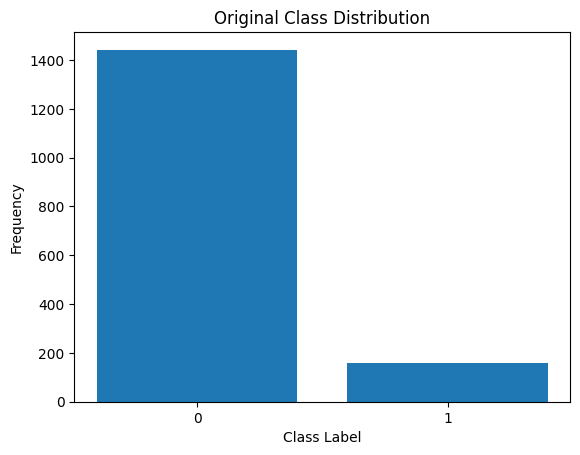

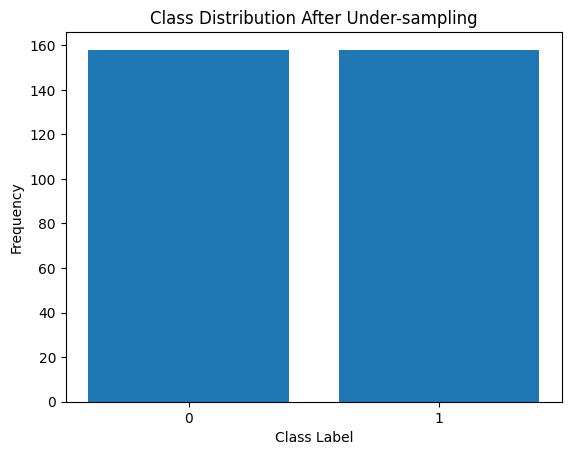

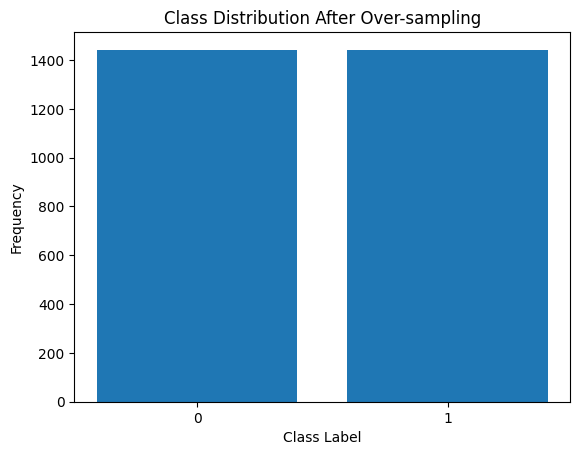

<Figure size 640x480 with 0 Axes>

In [ ]:
# Function to plot class distribution
def plot_class_distribution(y, title):
    # A reusable function, same pattern as Plot2D/Plot3D from the
    # earlier dimensionality-reduction notebooks — defined once,
    # called multiple times with different data and titles, so the
    # bar-plot code doesn't need to be repeated for each of the three
    # class-distribution checks.

    unique, counts = np.unique(y, return_counts=True)
    # Get the distinct class labels present in y (here, [0, 1]) along
    # with how many times each one occurs.
    #   - unique: array of distinct labels, e.g. [0, 1].
    #   - counts: array of matching counts, e.g. [1442, 158] for the
    #     original imbalanced training labels.
    # return_counts=True is what makes np.unique return both arrays
    # instead of just the unique values.

    plt.bar(unique, counts, tick_label=['0', '1'])
    # Draw a bar chart: one bar per class, with bar heights equal to
    # each class's count. tick_label=['0', '1'] explicitly labels the
    # two x-axis ticks as "0" and "1" (the class names), rather than
    # relying on the raw numeric positions.

    plt.title(title)
    plt.xlabel('Class Label')
    plt.ylabel('Frequency')
    # Standard matplotlib labeling: chart title (passed in per call),
    # x-axis labeled "Class Label", y-axis labeled "Frequency" (i.e.
    # count of samples).

    plt.savefig(f"{title}_slides.png")
    # Save the figure to disk as a PNG file, named after the title
    # (e.g. "Original Class Distribution_slides.png") — useful for
    # reusing these exact plots later (e.g. embedding them directly
    # into slides, matching the "_slides" suffix), rather than only
    # having them appear transiently in notebook output.

    plt.show() # to visualize the figures in the output

    plt.clf()
    # Clear the current matplotlib figure after saving. This is
    # IMPORTANT here specifically because the function is called
    # three times in a row: without clf() (clear figure), each new
    # call's bar() would draw on top of the previous plot's leftover
    # figure state, causing titles/bars to overlap or accumulate
    # across calls instead of each producing a clean, separate chart.

# Plot class distribution before and after re-sampling
plot_class_distribution(y_train, 'Original Class Distribution')
plot_class_distribution(y_train_rus, 'Class Distribution After Under-sampling')
plot_class_distribution(y_train_ros, 'Class Distribution After Over-sampling')
# Call the function three times, once per version of the training
# labels seen so far, producing three separate saved bar charts:


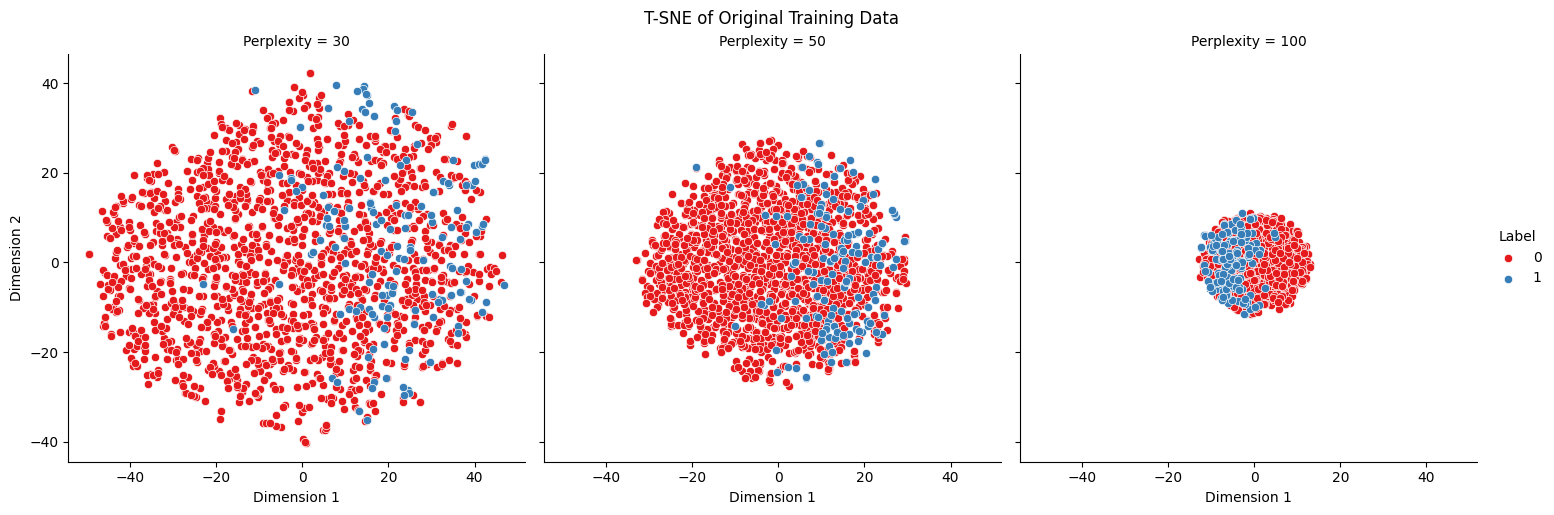

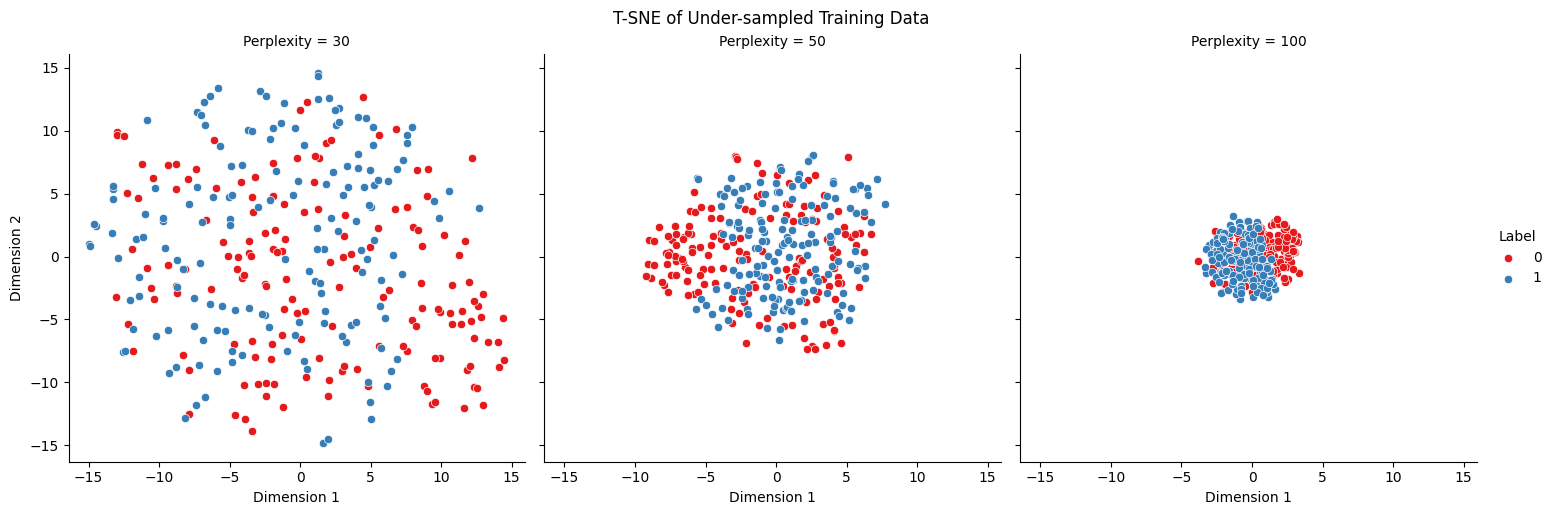

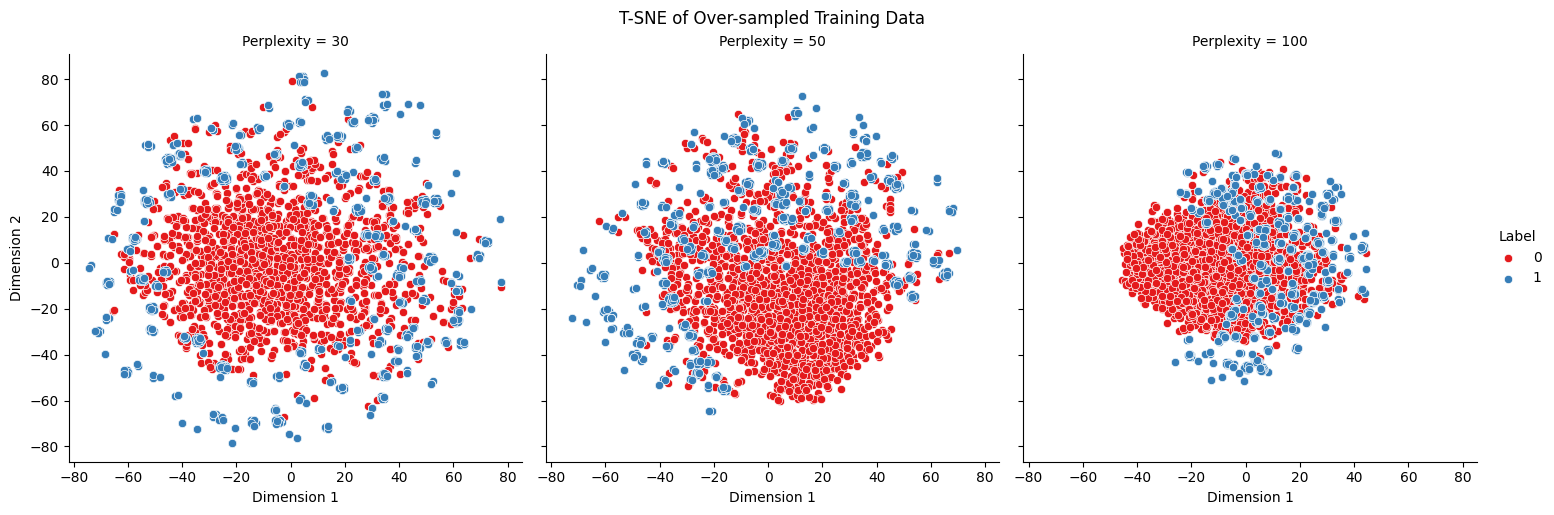

In [ ]:
import seaborn as sns
import pandas as pd
from sklearn.manifold import TSNE
# seaborn (aliased sns) is used here specifically for its FacetGrid —
# a tool for laying out multiple related subplots in a grid based on
# columns of a DataFrame, which is why pandas is also imported: the
# t-SNE results across different perplexity values will be collected
# into one DataFrame first, then faceted into side-by-side subplots.
# TSNE is the same class used in the earlier digits notebook.

def plot_tsne(X, y, title):
    # A reusable function: given a dataset X and its labels y, this
    # runs t-SNE at THREE DIFFERENT perplexity values and plots all
    # three results side by side — directly addressing the earlier
    # point that perplexity is a key hyperparameter that can change
    # the resulting cluster shapes, so trying a few values (rather
    # than trusting one) is good practice.

    # Create a DataFrame to hold the data
    data = pd.DataFrame()
    # An empty DataFrame that will accumulate the 2D t-SNE results
    # from all three perplexity runs, stacked into one long table.

    for perplexity in [30, 50, 100]:
        # Loop over three perplexity values to compare: 30 (the
        # scikit-learn default), 50, and 100 — progressively
        # considering a larger "effective neighborhood" per point.

        tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity)
        X_tsne = tsne.fit_transform(X)
        # Run the full t-SNE pipeline (as explained in detail earlier:
        # build similarity distribution P via Gaussians in the
        # original space, initialize points in 2D, build Q via
        # t-distribution, then iteratively minimize KL divergence)
        # on X, using this loop iteration's perplexity value.
        # random_state=42 fixes t-SNE's random initialization, so
        # re-running this cell reproduces the same layout each time —
        # important given t-SNE's randomness was flagged earlier as a
        # source of run-to-run variability.

        # Adding the data to the DataFrame
        temp_df = pd.DataFrame(X_tsne, columns=['Dimension 1', 'Dimension 2'])
        # Wrap this run's 2D output into a small DataFrame with named
        # columns 'Dimension 1' and 'Dimension 2' — matching the axis
        # labels used in the earlier Plot2D helper function.

        temp_df['Perplexity'] = perplexity
        # Add a column recording WHICH perplexity value produced each
        # row — this is the column FacetGrid will later split subplots
        # on.

        temp_df['Label'] = y
        # Add a column with the true class label for each point (here,
        # 0 or 1, from the imbalanced dataset) — this is what will
        # color the points within each subplot.

        data = pd.concat([data, temp_df], ignore_index=True)
        # Append this perplexity run's results onto the growing `data`
        # DataFrame. ignore_index=True re-numbers the combined rows
        # sequentially (0, 1, 2, ...) rather than keeping each temp_df's
        # own separate 0-based index, avoiding duplicate index values
        # across the three concatenated chunks.
        # After all 3 iterations, `data` has 3 * len(X) rows total —
        # one full copy of the data for each perplexity value, all in
        # one long table, differing only in the 'Dimension 1/2' values
        # and the 'Perplexity' column.

    # Using FacetGrid to create a grid of plots
    grid = sns.FacetGrid(data, col="Perplexity", hue="Label", palette="Set1", height=5)
    # Set up a grid of subplots:
    #   - col="Perplexity": creates one subplot PER DISTINCT value in
    #     the Perplexity column — since there are 3 (30, 50, 100),
    #     this produces 3 subplots side by side automatically.
    #   - hue="Label": within each subplot, color points by the Label
    #     column (class 0 vs. class 1) — same coloring concept used
    #     throughout (Iris species, Swiss roll position, digit value).
    #   - palette="Set1": a qualitative color palette (distinct,
    #     high-contrast colors) — suited to a small number of
    #     categorical classes like 0/1 here.
    #   - height=5: sets each individual subplot's height (in inches);
    #     width is determined automatically to keep a reasonable aspect
    #     ratio, and the OVERALL figure width scales with the number of
    #     subplots (3 here).
    # At this point, only the grid's layout is defined — no data has
    # actually been drawn into the subplots yet.

    grid.map_dataframe(sns.scatterplot, x='Dimension 1', y='Dimension 2')
    # Fill in every subplot in the grid with a scatterplot of
    # Dimension 1 vs. Dimension 2, automatically using only the rows
    # of `data` matching that subplot's Perplexity value, and coloring
    # by Label as configured above. This single line effectively draws
    # all 3 scatterplots (one per perplexity) in one call.

    grid.add_legend()
    # Add a single shared legend (mapping colors to Label values)
    # to the overall figure, rather than repeating a legend inside
    # each of the 3 subplots individually.

    grid.fig.suptitle(title, y=1.02)  # Adjust title position for better appearance
    # Add an overall title ABOVE the entire grid of 3 subplots (not
    # per-subplot) — accessed via grid.fig (the underlying matplotlib
    # Figure object that FacetGrid manages). y=1.02 nudges the title
    # slightly above the default position (slightly above y=1.0, the
    # top of the axes), preventing it from overlapping the subplot
    # titles FacetGrid automatically adds (e.g. "Perplexity = 30").

    plt.show()
    # Actually display the completed 3-subplot figure — note this
    # function DOES call plt.show() (unlike the class-distribution bar
    # plot function from before), so this one will render inline in
    # Colab without needing any fix.

# Call the function for original, under-sampled, and over-sampled data
plot_tsne(X_train, y_train, 'T-SNE of Original Training Data')
plot_tsne(X_train_rus, y_train_rus, 'T-SNE of Under-sampled Training Data')
plot_tsne(X_train_ros, y_train_ros, 'T-SNE of Over-sampled Training Data')
# Call the function three times — once per version of the training
# set built earlier (original imbalanced, under-sampled, over-sampled)
# — each call internally running t-SNE 3 TIMES (once per perplexity),
# so this cell runs t-SNE 9 times in total. Each call produces its own
# 3-subplot figure, giving 3 total figures (9 subplots overall) to
# compare.
